# 初始化文件路径，转换中文字符

In [63]:
import os

name = "tanpeng"

file_path = f"exp/qinzhou1/{name}"
data_path = f"./data/qinzhouVideo/TICVideos/{name}"

origin_video_path = os.path.join(data_path, f"{name}_cut.mp4")  # 原始视频
yolo_video_path = os.path.join(file_path, f"{name}_yolo.mp4")         # yolo视频
labels_path = os.path.join(file_path, 'labels')                 # yolo每一帧标签 

print(file_path, origin_video_path, yolo_video_path, labels_path, sep='\n') 

exp/qinzhou1/tanpeng
./data/qinzhouVideo/TICVideos/tanpeng/tanpeng_cut.mp4
exp/qinzhou1/tanpeng/tanpeng_yolo.mp4
exp/qinzhou1/tanpeng/labels


# 读取视频，查看视频信息

In [64]:
import cv2
import os, re, shutil
from matplotlib import pyplot as plt
from tqdm import tqdm
from copy import deepcopy

# 若路径文件名包含中文字符、全角字符，使用目录名代替文件名，从而重命名视频文件
def convert_path(path):
    basename = os.path.basename(path)
    replaced_basename = re.sub(r'[\u4e00-\u9fa5\uFF00-\uFFEF]', '', basename)
    
    if basename == replaced_basename:
        return path
    
    dir = os.path.dirname(path) 
    dir_name = os.path.basename(dir)
    replaced_path = os.path.join(dir, dir_name+os.path.splitext(path)[1])
    if os.path.exists(path):
        os.rename(path, replaced_path)
    else:
        print(f"File [{path}] does not exist. It has been renamed or deleted.")
    return replaced_path

# 复制源视频到当前目录
if not os.path.exists(os.path.join(file_path, os.path.basename(origin_video_path))):
    name = os.path.basename(origin_video_path)
    name = name.replace("cut.mp4", "origin.mp4")
    shutil.copy2(origin_video_path, os.path.join(file_path, name))
    print(f"Origin video file copy: {origin_video_path} -> {os.path.join(file_path, name)}")

# 复制软件标注到当前目录，软件标注中有~$开头的微软临时文件，需要删除
if not os.path.exists(os.path.join(file_path, 'NO NAME')):
    l = os.listdir(os.path.dirname(origin_video_path))
    dir_name = ''
    for name in l:
        if name.startswith('NO NAME'):
            dir_name = name
            break
    shutil.copytree(os.path.join(os.path.dirname(origin_video_path), dir_name), os.path.join(file_path, 'NO NAME'))
    print(f"NO NAME file copy: {os.path.join(os.path.dirname(origin_video_path), 'NO NAME')} -> {file_path}")
    
    no_name_path = os.path.join(file_path, 'NO NAME')
    for file in os.listdir(no_name_path):
        if file.startswith('~$'):
            os.remove(os.path.join(no_name_path, file))

# 转换路径，文件名有中文则重命名为目录名
origin_video_path = convert_path(os.path.join(file_path, os.path.basename(origin_video_path).replace("cut.mp4", "origin.mp4")))
yolo_video_path = convert_path(yolo_video_path)

print(f"Origin video path: {origin_video_path}\nYolo video path: {yolo_video_path}")

cap_origin = cv2.VideoCapture(origin_video_path)
cap = cv2.VideoCapture(yolo_video_path)
format = cap.get(cv2.CAP_PROP_FORMAT)
fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
width, height = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
print('视频格式：', format)
print('视频时长：', frame_count/fps, '秒')
print('帧率：', fps)
print('总帧数：', frame_count)
print('视频尺寸：', width, height)
# print('视频类型：', file_type)

if not cap.isOpened() and cap_origin.isOpened():
    print('视频打开失败！')

frame_list = []  
frame_origin_list = []
pbar = tqdm(total=int(frame_count), desc='Extarcting frames')

while True:
    ret, frame = cap.read() # img 就是一帧图片 
    ret_1, frame_origin = cap_origin.read()
    if not (ret and ret_1):
        break      
    frame_list.append(frame)
    frame_origin_list.append(frame_origin)
    pbar.update(1)


frame_pure_noModified_list = deepcopy(frame_origin_list)   
pbar.close()

cap.release()
cap_origin.release()

print(frame_origin_list.__len__())

Origin video file copy: ./data/qinzhouVideo/TICVideos/tanpeng/tanpeng_cut.mp4 -> exp/qinzhou1/tanpeng/tanpeng_origin.mp4
Origin video path: exp/qinzhou1/tanpeng/tanpeng_origin.mp4
Yolo video path: exp/qinzhou1/tanpeng/tanpeng_yolo.mp4
视频格式： 0.0
视频时长： 38.6 秒
帧率： 10.0
总帧数： 386.0
视频尺寸： 1280 960


Extarcting frames: 100%|██████████| 386/386 [00:01<00:00, 265.99it/s]

386


# 寻找造影区域和超声区域边界

rect0 = (263, 570, 759, 325)
rect1 = (265, 171, 757, 305)
Ultrasound and contrast are parted, choose....
Choose vertically: 
Ultrasound: (263, 570, 759, 325), Contrast: (263, 151, 759, 325), y_offset: -419



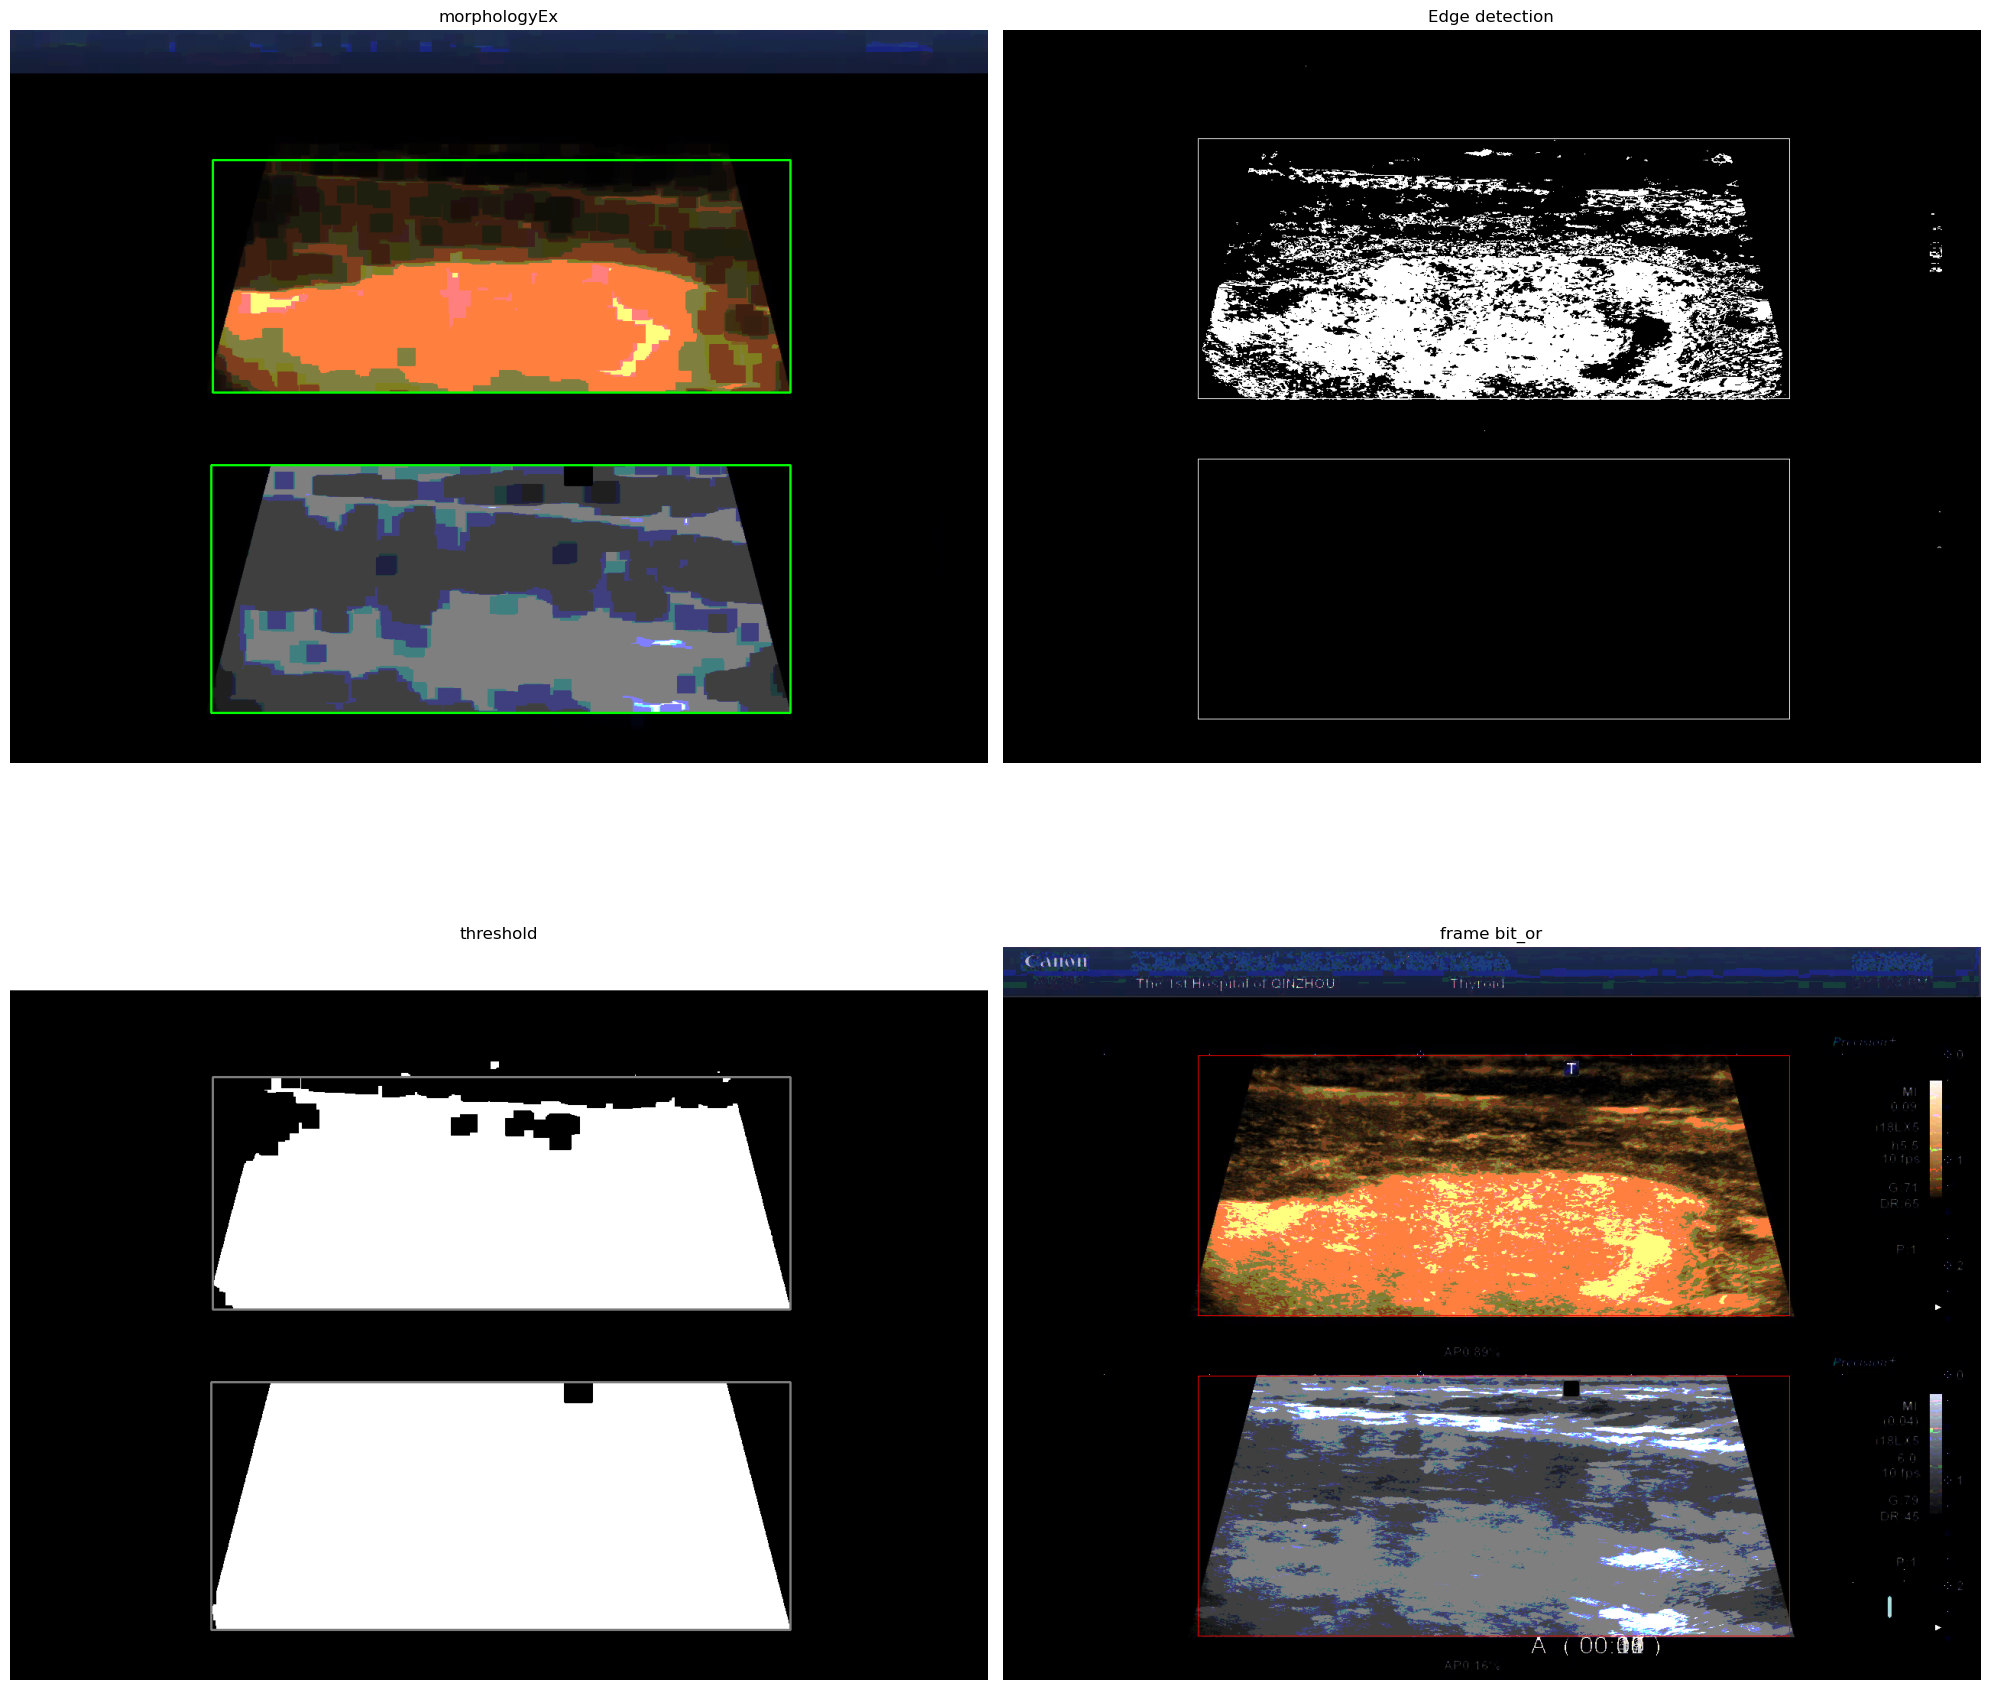

In [65]:

import copy
import random
import numpy as np
import matplotlib.pyplot as plt


# 帧间或，运动区域会愈发亮，闭运算，先膨胀再腐蚀，连接大块区域
# sample step：每隔step帧取一帧
#        random：随机取
def get_limit_rect(frame_origin_list, sample="step"):
    rect_ultrasound = []  # 灰度区域
    rect_contrast = []  # 造影区域
    x_offset = 0  # 灰度向左偏移x即是造影
    y_offset = 0  # 灰度向上偏移y即是造影

    overlap_ratio = 0.3
    frame_sample = []
    frame = copy.deepcopy(frame_origin_list[0])

    # 抽取帧，计算帧或图像
    if sample == "step":
        step = int(1 / 0.3)
        frame_sample = frame_origin_list[::step]
    elif sample == "random":
        frame_sample = random.sample(frame_origin_list, int(len(frame_origin_list) * overlap_ratio))

    # 或之间腐蚀图像，消除细小文字之类
    kernel = np.ones((3, 3))
    frame = cv2.erode(frame, kernel)
    for f in frame_sample:
        f = cv2.erode(f, kernel)
        frame = cv2.bitwise_or(frame, f)

    fig, ax = plt.subplots(2, 2, figsize=(20, 20))
    ax[0][0].axis("off")
    ax[0][1].axis("off")
    ax[1][0].axis("off")
    ax[1][1].axis("off")

    # 图像形态学运算
    kernel = np.ones((5, 5))
    close = cv2.morphologyEx(frame, cv2.MORPH_CLOSE, kernel)

    kernel = np.ones((5, 15))
    close = cv2.erode(close, kernel)
    kernel = np.ones((15, 5))
    close = cv2.erode(close, kernel)
    # kernel = np.ones((20, 20))
    # close = cv2.erode(close, kernel)

    # 灰度二值化
    gray = cv2.cvtColor(close, cv2.COLOR_BGR2GRAY)
    _, threshold = cv2.threshold(gray, 20, 255, cv2.THRESH_BINARY)
    
    # Canny 边缘检测方法，造影区域轮廓比较多
    # edge = cv2.Canny(frame, 0, 150)
    # edge = cv2.dilate(edge, np.ones((2, 2))) 

    # HSV 边缘检测方法
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

    # 红色在HSV空间中的阈值
    lower_color = np.array([0, 120, 70])
    upper_color = np.array([10, 255, 255])
    # 对于红色，可能需要两个区间来覆盖180度的色相变化
    lower_color2 = np.array([170, 120, 70])
    upper_color2 = np.array([180, 255, 255])

    # 创建掩码
    mask1 = cv2.inRange(hsv, lower_color, upper_color)
    mask2 = cv2.inRange(hsv, lower_color2, upper_color2)
    edge = cv2.bitwise_or(mask1, mask2)

    # 寻找灰度边界，最大的两个外接矩形
    cnt, _ = cv2.findContours(threshold, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cnt_bounding_rect = [cv2.boundingRect(c) for c in cnt]
    # 将外接矩形面积从大到小排序，选择最大的
    c = sorted(cnt_bounding_rect, key=lambda x : x[2]*x[3], reverse=True) 
    rect0 = c[0]
    rect1 = c[1]
    print(f"rect0 = {rect0}\nrect1 = {rect1}")
    
    area0 = rect0[2] * rect0[3]
    area1 = rect1[2] * rect1[3]
    area_diff = abs(area0 - area1)

    # 面积差别过大，说明超声和造影连在一起了，需要分开
    if area_diff > 0.5 * area0 and area_diff > 0.5 * area1:
        print("Ultrasound and contrast are connected, need to separate....")

        rect = rect0 if area0 > area1 else rect1
        x, y, w, h = rect
        # 边缘有的是黑的，影响检测，所以加上内边距
        padding_w = int(0.1 * w)
        padding_h = int(0.1 * h)
        
        # 横区域对比
        rect_w1 = (x, y, w // 2, h)
        rect_w2 = (x + w // 2, y, w // 2, h)
        brightness_w1 = np.mean(
            edge[
                rect_w1[1] + padding_h : rect_w1[1] + rect_w1[3] - padding_h,
                rect_w1[0] + padding_w : rect_w1[0] + rect_w1[2] - padding_w,
            ]
        )
        brightness_w2 = np.mean(
            edge[
                rect_w2[1] + padding_h : rect_w2[1] + rect_w2[3] - padding_h,
                rect_w2[0] + padding_w : rect_w2[0] + rect_w2[2] - padding_w,
            ]
        )
        diff_w = abs(brightness_w1 - brightness_w2)
        print(
            f"Brightness left: {brightness_w1:.2f}, Brightness right: {brightness_w2:.2f}, Diff: {diff_w:.2f}"
        )

        # 纵区域对比
        rect_h1 = (x, y, w, h // 2)
        rect_h2 = (x, y + h // 2, w, h // 2)
        brightness_h1 = np.mean(
            edge[
                rect_h1[1] + padding_h: rect_h1[1] + rect_h1[3] - padding_h,
                rect_h1[0] + padding_w: rect_h1[0] + rect_h1[2] - padding_w,
            ]
        )
        brightness_h2 = np.mean(
            edge[
                rect_h2[1] + padding_h: rect_h2[1] + rect_h2[3] - padding_h,
                rect_h2[0] + padding_w: rect_h2[0] + rect_h2[2] - padding_w,
            ]
        )
        diff_h = abs(brightness_h1 - brightness_h2)
        print(
            f"Brightness top: {brightness_h1:.2f}, Brightness bottom: {brightness_h2:.2f}, Diff: {diff_h:.2f}"
        )

        if diff_w > diff_h:
            # 横向切割
            # 左CEUS 右US
            rect_contrast = (x, y, w // 2, h)
            rect_ultrasound = (x + w // 2, y, w // 2, h)
            x_offset = -w // 2
            
            # 右CEUS 左US
            if brightness_w2 > brightness_w1:
                rect_ultrasound = (x, y, w // 2, h)
                rect_contrast = (x + w // 2, y, w // 2, h)
                x_offset = w // 2
                
            print(
                f"Cut horizontally: \nUltrasound: {rect_ultrasound}, Contrast: {rect_contrast}, x_offset: {x_offset}\n"
            )
            cv2.rectangle(edge, rect_w1, (255, 255, 255), 2)
            cv2.rectangle(edge, rect_w2, (255, 255, 255), 2)
        else:
            # 纵向切割
            # 上CEUS 下US
            rect_contrast = (x, y, w, h // 2)
            rect_ultrasound = (x, y + h // 2, w, h // 2)
            y_offset = -h // 2
            
            # 下CEUS 上US
            if brightness_h2 > brightness_h1:
                rect_ultrasound = (x, y, w, h // 2)
                rect_contrast = (x, y + h // 2, w, h // 2)
                y_offset = h // 2
                
            print(
                f"Cut vertically: \nUltrasound: {rect_ultrasound}, Contrast: {rect_contrast}, y_offset: {y_offset}\n"
            )
            cv2.rectangle(edge, rect_h1, (255, 255, 255), 2)
            cv2.rectangle(edge, rect_h2, (255, 255, 255), 2)

    # 面积相差不大，没有连接在一起，选择右下面的框作为超声，左上面的框作为造影
    else:
        print("Ultrasound and contrast are parted, choose....")

        diff_x = abs((rect0[0] + rect0[2]) - (rect1[0] + rect1[2]))
        diff_y = abs((rect0[1] + rect0[3]) - (rect1[1] + rect1[3]))  # 一般右底下的超声叠加更亮，而且造影下方一般也会更亮

        brightness0 = np.mean(
            edge[
                rect0[1]: rect0[1] + rect0[3],
                rect0[0]: rect0[0] + rect0[2],
            ]
        )
        brightness1 = np.mean(
            edge[
                rect1[1]: rect1[1] + rect1[3],
                rect1[0]: rect1[0] + rect1[2],
            ]
        )
        
        # 横向分布
        if diff_x > diff_y:
            x_offset = diff_x
            (x_right, y_right, w_right, h_right) = rect0 if rect0[0] > rect1[0] else rect1 # 右边的框
            (x, y, w, h) = rect0 if brightness0 < brightness1 else rect1 # 选择更暗的框作为超声
            
            # 右边框超声那左边就是造影，offset + US = CEUS，所以x_offset = -diff_x
            if x == x_right and y == y_right and w == w_right and h == h_right:
                x_offset = -diff_x
                
            rect_contrast = (x + x_offset, y, w, h)
            rect_ultrasound = (x , y, w, h)
            print(
                f"Choose horizontally: \nUltrasound: {rect_ultrasound}, Contrast: {rect_contrast}, x_offset: {x_offset}\n"
            )
        # 纵向分布
        else:
            y_offset = diff_y
            (x_bottom, y_bottom, w_bottom, h_bottom) = rect0 if rect0[1] > rect1[1] else rect1 # 下边的框
            (x, y, w, h) = rect0 if brightness0 < brightness1 else rect1 # 选择更暗的框作为超声
            
            # 下边框超声那上边就是造影，offset + US = CEUS，所以y_offset = -diff_y
            if x == x_bottom and y == y_bottom and w == w_bottom and h == h_bottom:
                y_offset = -diff_y
                
            rect_contrast = (x, y + y_offset, w, h)
            rect_ultrasound = (x, y, w, h)
            print(
                f"Choose vertically: \nUltrasound: {rect_ultrasound}, Contrast: {rect_contrast}, y_offset: {y_offset}\n"
            )

    # 弥补形态学变换导致的框缩小，前提是加padding后框仍然在图像范围内
    padding = 8
    if rect_contrast[0] - padding > 0 and rect_contrast[1] - padding > 0 and \
       rect_contrast[0] + rect_contrast[2] + 2 * padding < width and rect_contrast[1] + rect_contrast[3] + 2 * padding < height and \
       rect_ultrasound[0] - padding > 0 and rect_ultrasound[1] - padding > 0 and \
       rect_ultrasound[0] + rect_ultrasound[2] + 2 * padding < width and rect_ultrasound[1] + rect_ultrasound[3] + 2 * padding < height:
        rect_ultrasound = (
            rect_ultrasound[0] - padding,
            rect_ultrasound[1] - padding,
            rect_ultrasound[2] + 2 * padding,
            rect_ultrasound[3] + 2 * padding,
        )
        rect_contrast = (
            rect_contrast[0] - padding,
            rect_contrast[1] - padding,
            rect_contrast[2] + 2 * padding,
            rect_contrast[3] + 2 * padding,
        )

    cv2.rectangle(close, rect0, (0, 255, 0), 2)
    cv2.rectangle(close, rect1, (0, 255, 0), 2)
    
    cv2.rectangle(threshold, rect0, (125, 125, 125), 2)
    cv2.rectangle(threshold, rect1, (125, 125, 125), 2)
    
    cv2.rectangle(edge, rect_ultrasound, (255, 255, 255), 1)
    cv2.rectangle(edge, rect_contrast, (255, 255, 255), 1)

    cv2.rectangle(frame, rect_ultrasound, (0, 0, 255), 1)
    cv2.rectangle(frame, rect_contrast, (0, 0, 255), 1)

    ax[0][0].set_title("morphologyEx")
    ax[0][0].imshow(cv2.cvtColor(close, cv2.COLOR_BGR2RGB))
    
    ax[0][1].set_title("Edge detection")
    ax[0][1].imshow(cv2.cvtColor(edge, cv2.COLOR_BGR2RGB))

    ax[1][0].set_title("threshold")
    ax[1][0].imshow(cv2.cvtColor(threshold, cv2.COLOR_BGR2RGB))

    ax[1][1].set_title("frame bit_or")
    ax[1][1].imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

    fig.tight_layout()
    plt.savefig(os.path.join(file_path, 'find rect.png'))
    
    return rect_ultrasound, rect_contrast, x_offset, y_offset


rect_ultrasound, rect_contrast, x_offset, y_offset = get_limit_rect(frame_origin_list)

# 寻找缺失帧，具有多个识别标签的帧

In [66]:
import os 

# 获取文件名中的帧索引，从1开始
def get_file_index(file_name):
    return int(file_name.split('_')[-1].split('.txt')[0])


# 找到有多个标签的帧
# shz103.mp4 多标签的帧 ['1094', '1101', '1102', '404', '918', '1100', '568']
def find_muti_lables(lables_path):
    l = os.listdir(lables_path)
    muti_lables = []
    for file_name in l:
        lines_list = []
        with open(os.path.join(lables_path, file_name), 'r', encoding='utf-8') as file:  # 确保使用正确的编码
            for line in file:
                lines_list.append(line.strip())
        if lines_list.__len__() > 1:
            muti_lables.append(int(file_name.split('_')[-1].split('.')[0]))
    muti_lables.sort()
    return muti_lables


# 获取丢失的帧列表和字典
def get_lost_frame(lables_path):
    lost_frame = []    
    lost_frame_dict = {}
    l = os.listdir(lables_path)
    l.sort(key=lambda x:int(get_file_index(x)))
    
    if len(l) == 0:
        print(f'{file_path} has no labels! EXIT....')
        exit()
    
    for index, file in enumerate(l):
        # 视频首帧缺失
        if index == 0 and get_file_index(file) != 1:
            lost_frame.extend(list(range(1, get_file_index(file))))
            lost_frame_dict[1] = list(range(1, get_file_index(file)))
            continue
        elif index == 0 and get_file_index(file) == 1:
            continue
            
        # 其他帧缺失    
        last_file_index = get_file_index(l[index-1])
        if not file.endswith(f'_{last_file_index+1}.txt'):
            begin = last_file_index + 1
            end = get_file_index(file)
            lost_frame.extend(list(range(begin, end)))
            lost_frame_dict[begin] = list(range(begin, end))
    
    # 对于末尾帧缺失的情况
    if get_file_index(l[-1]) != int(frame_count):
        begin = get_file_index(l[-1]) + 1
        end = int(frame_count) + 1  # +1 是为了包含最后一帧 range不包含右边界
        lost_frame.extend(list(range(begin, end)))
        lost_frame_dict[begin] = list(range(begin, end))
        
    return lost_frame, lost_frame_dict

lost_frame, lost_frame_dict = get_lost_frame(labels_path)
muti_labels_frame = find_muti_lables(labels_path)
print("Lost frame list:", lost_frame)
print("Missing frame list:", lost_frame_dict)
print("Multi-label frame list:", muti_labels_frame)
print('')

Lost frame list: [1, 2, 8, 9, 10, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 32, 46, 51, 54, 78, 80, 84, 179, 199, 200, 205, 206, 207, 208, 209, 210, 211, 212, 217, 218, 221, 223, 228, 229, 230, 231, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246, 255, 257, 258, 259, 273, 291, 293, 294, 295, 296, 297, 299, 301, 302, 311, 315, 319, 320, 321, 322, 323, 324, 325, 326, 327, 328, 329, 330, 331, 332, 333, 335, 336, 338, 342, 346, 350, 356, 357, 359, 360, 374, 376, 378, 380, 383, 384]
Missing frame list: {1: [1, 2], 8: [8, 9, 10], 13: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25], 32: [32], 46: [46], 51: [51], 54: [54], 78: [78], 80: [80], 84: [84], 179: [179], 199: [199, 200], 205: [205, 206, 207, 208, 209, 210, 211, 212], 217: [217, 218], 221: [221], 223: [223], 228: [228, 229, 230, 231], 234: [234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 244, 245, 246], 255: [255], 257: [257, 258, 259], 273: [273], 291: [291], 293: [293, 294, 295, 296, 297], 299: [299]

# 替换缺失帧（之前接近的帧替代缺失帧）

In [67]:
# 找到之前接近的帧替代缺失帧
def replace_lost_frame(frame_index):
    for key in lost_frame_dict.keys():
            if frame_index in lost_frame_dict[key]:
                origin_frame_index = frame_index
                
                # 若缺失帧恰好为第一帧，用随后的帧代替
                if lost_frame_dict[key][0] == 1:
                    frame_index = lost_frame_dict[key][-1]+1
                # 否则直接用之前接近的帧替代
                else:
                    frame_index = lost_frame_dict[key][0]-1
                
                print(f"Missing frame area: {lost_frame_dict[key]}")  
                print(f"Replace missing frame: {origin_frame_index} -> {frame_index}")
                break
    return frame_index

replace_lost_frame(2)

Missing frame area: [1, 2]
Replace missing frame: 2 -> 3


3

# 从标签文件获取标签框信息

In [68]:
import numpy as np
import cv2

# 从label.txt文件中获取class，polygon，rect，confidence信息
def get_label_info(label_file):
    lines_list = []
    with open(label_file, 'r', encoding='utf-8') as file:  # 确保使用正确的编码
        for line in file:
            lines_list.append(line.split())

    # 对于有帧内的标签
    class_list = []         # 每个分割框的类别
    confidence_list = []    # 每个分割框的置信度
    polygon_list = []       # 分割框的坐标列表
    rect_list = []          # 分割框的中心点坐标

    # 对于每个分割框，获得其置信度、坐标和中心点
    for index, line in enumerate(lines_list):
        confidence_list.append([])
        polygon_list.append([])
        rect_list.append([])
        class_list.append([])
        class_list[index].append(line[0])
        confidence_list[index].append(line[-1])
        line.pop(0)
        line.pop(-1)

        l = np.array(line, dtype=np.float32)
        for i in range(0, len(l), 2):
            polygon_list[index].append([int(l[i]*width), int(l[i+1]*height)])

        polygon_list[index] = np.array(polygon_list[index])

        # 识别轮廓超出超声区域矩形框的情况，裁剪超出矩形框的部分
        x, y, w, h = rect_ultrasound
        rect_right = x + w
        rect_bottom = y + h

        polygon_list[index] = np.clip(
            polygon_list[index],
            a_min=[x, y],
            a_max=[rect_right, rect_bottom],  # 矩形的左上角
        )

        x, y, w, h = cv2.boundingRect(polygon_list[index])
        rect_list[index].extend([x, y, w, h])

    return class_list, polygon_list, rect_list, confidence_list

file = os.path.join(labels_path, os.listdir(labels_path)[0])
class_list, polygon_list, rect_list, confidence_list = get_label_info(file)

print(f'EXAMPLE  File: {file} Class: {class_list} PolyLen: {len(polygon_list)} Rect: {rect_list} Confidence: {confidence_list}\n')

EXAMPLE  File: exp/qinzhou1/tanpeng/labels/tanpeng_cut_381.txt Class: [['0']] PolyLen: 1 Rect: [[783, 721, 101, 61]] Confidence: [['0.38024']]



# 处理帧间标签位置偏移及多个标签问题

In [69]:
import copy, math

distance_threshold = 50
confidence_threshold = 0.7

# 保存历史帧的标签信息 
history_dict = {    
    'replaced_frame': 0,      # 帧是否缺失，没缺失默认是0，缺失就是替换帧的索引值    
    'distance': 10,           # 帧的标签中心点距离
    'confidence': [],         # 帧的标签置信度
    'rect': [],               # 帧的标签外接矩形
    'polygon': [],            # 帧的标签边框坐标   
    'brightness': [],         # 帧的亮度 灰度、造影 target cmp limit_rect
}
history = [copy.deepcopy(history_dict) for _ in range(int(frame_count))]

def print_history(l):
    for index, h in enumerate(history):
        if index in l:
            print('[HISTORY] Frame: {}, Replaced frame: {}, Confidence: {}, PolyLen: {}'
                  .format(index, h['replaced_frame'], h['confidence'], len(h['polygon'])))


# 从rect x y w h中获取中心点坐标
def get_center(rect: list):
    x = int(rect[0] + rect[2]/2) 
    y = int(rect[1] + rect[3]/2) 
    return [x, y]


def get_area(rect: list):
    w = rect[2]
    h = rect[3]
    return w * h


def get_distance(point1, point2):
    x1, y1 = point1
    x2, y2 = point2
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)


# 处理多个标签和标签位置偏移
def process_history_labels(history, frame_index):
    distance = []
    area = []
    label_num = len(history[frame_index]['confidence'])
    
    # 如果第一帧就有多个标签，则保留置信度最高的标签，没有多个标签就跳过第一帧
    if frame_index == 1:
        print(history[frame_index]['confidence'])
        if label_num > 1:
            reserve_label_index = history[frame_index]['confidence'].index(max(history[frame_index]['confidence']))
            history[frame_index]['confidence'] = [history[frame_index]['confidence'][reserve_label_index]]
            history[frame_index]['rect'] = [history[frame_index]['rect'][reserve_label_index]]
            history[frame_index]['polygon'] = [history[frame_index]['polygon'][reserve_label_index]]
            return
        # 第一帧置信度太低，往后找到一个高点的替代
        elif float(max((history[frame_index]['confidence'][0]))) < confidence_threshold:
            for i in range(2, int(frame_count)):
                if i not in lost_frame:
                    # 找到对应的label文件
                    label_file = os.listdir(labels_path)[0]
                    start = label_file.rfind('_') + 1
                    label_file = os.path.join(labels_path, label_file[:start] + f'{i}.txt')
                    
                    # 获取标签信息
                    _, polygon_list, rect_list, confidence_list = get_label_info(label_file) 
                    print(rect_list, confidence_list)
                    
                    # 使用高的替代
                    if float(max(confidence_list[0])) > confidence_threshold:
                        max_index = confidence_list[0].index(max(confidence_list[0]))
                        print(f'frame {frame_index} confidence too low, replace with frame {i}, confidence {max(confidence_list[0])}, rect {rect_list[max_index]}')
                        history[frame_index]['confidence'] = [max(confidence_list[0])]
                        history[frame_index]['rect'] = [history[frame_index]['rect'][max_index]]
                        history[frame_index]['polygon'] = [history[frame_index]['polygon'][max_index]]
                        return
        return
    
    
    last_frame = 0
    # 这一帧未被替换过
    if history[frame_index]['replaced_frame'] == 0:
        last_frame = frame_index-1
    # 被替换过，则找到替换前的最后一帧
    else:
        last_frame = history[frame_index]['replaced_frame']
        while history[last_frame]['replaced_frame'] != 0:
            last_frame -= 1
        print('Frame has been replaced: {} -> {}'.format(frame_index, last_frame))

    print('Last frame: {}'.format(last_frame))
    print('Current frame: {}'.format(frame_index))

    last_center_point = get_center(history[last_frame]['rect'][0])
    last_area = get_area(history[last_frame]['rect'][0])
    
    # 先处理有多个标签的情况，依次判断距离、面积、置信度
    if label_num > 1:
        reserve_label_index = 0
        
        # 计算每个标签与上一帧标签的距离和面积差值
        for i in range(label_num):      
            distance.append(get_distance(
                            get_center(history[frame_index]['rect'][i]), last_center_point))
            area.append(get_area(history[frame_index]['rect'][i]))
            print('Current Rect: {}  Distance: {}'.format(history[frame_index]['rect'][i], distance[i]))
            
        # 如果与上一帧距离最小的标签都超过阈值了，直接选择置信度最高的标签
        if min(distance) > distance_threshold:
            print('!!Warring: All labels are too far away from the last frame, reserve the label with the highest confidence.')
            # reserve_label_index = area.index(min([abs(i-last_area) for i in area]))            
            reserve_label_index = history[frame_index]['confidence'].index(max(history[frame_index]['confidence']))
            history[frame_index]['distance'] = distance_threshold*0.8
        
        # 否则在面积相差不大的中选择置信度高的
        else:
            distance = np.array(distance)
            area_ratio = np.array([i / last_area for i in area])
            
            # 过滤距离大的
            distance_mask = distance > distance_threshold
            area_ratio[distance_mask] = 0

            # 过滤面积相差大的
            area_mask = (area_ratio > 1.3) | (area_ratio < 0.7)
            area_ratio[area_mask] = 0
                        
            # 没有面积相差不大的，在距离相差不大的中选择置信度高的
            if sum(area_ratio) == 0:
                confidence = np.array(history[frame_index]['confidence'])
                confidence[distance_mask] = 0
                reserve_label_index = np.argmax(confidence)
                # reserve_label_index = confidence.index(max(confidence))
            
            # 有面积相差不大的，再在其中选择置信度高的
            else:
                confidence = np.array(history[frame_index]['confidence'])
                confidence[area_ratio==0] = 0
                reserve_label_index = np.argmax(confidence)
                # reserve_label_index = confidence.index(max(confidence))
        
        # 仅保留计算得到的标签
        history[frame_index]['distance'] = distance[reserve_label_index]        
        history[frame_index]['confidence'] = [history[frame_index]['confidence'][reserve_label_index]]
        history[frame_index]['rect'] = [history[frame_index]['rect'][reserve_label_index]]
        history[frame_index]['polygon'] = [history[frame_index]['polygon'][reserve_label_index]]
        
        print('Distance: {}\nReserve label: {} \nReserve rect: {} \nReserve confidence: {}'
              .format(distance, reserve_label_index, history[frame_index]['rect'], history[frame_index]['confidence']))
        
    # 只有一个标签，直接保留，注意此时要计算距离，因为获取信息时可能有多个标签未处理
    # 在这里相当于是分治，前面的帧处理好了，循环下去所有帧都处理好了
    else:
        history[frame_index]['distance'] = get_distance(get_center(history[frame_index]['rect'][0]), last_center_point)
    
    # 处理标签偏移的情况
    if history[frame_index]['distance'] > distance_threshold:
        # 当前帧可能已被替换
        replace = last_frame
        
        # 如果前一帧距离还是大于阈值，则继续替换
        while history[replace]['distance'] > distance_threshold:
            replace -= 1
         
        # 如果前一帧还是提环帧，则继续替换，直到找到被替换的帧复制其值   
        while history[replace]['replaced_frame'] != 0:
            replace = history[replace]['replaced_frame']
            
        # 替换当前帧，并记录替换的帧
        history[frame_index] = copy.deepcopy(history[replace])
        history[frame_index]['replaced_frame'] = replace 
        
        print('Distance: {} -> {}'.format(history[frame_index]['distance'], history[replace]['distance']))
        print('Replace frame: {} -> {}'.format(frame_index, replace))
    
    print('Current Rect: {}  Distance: {}'.format(history[frame_index]['rect'][0], history[frame_index]['distance']))

# 选取对比框并计算达峰帧

In [70]:
import numpy as np
import random
import math


# 获取两个矩形框的外接矩形，返回rect元组，可以设置内边距
def get_padding_bounding_rect(rect1, rect2, limit_rect, padding=20):
    x1, y1, w1, h1 = rect1
    x2, y2, w2, h2 = rect2

    # 顶点坐标
    p1 = (x1, y1)
    p2 = (x1 + w1, y1)
    p3 = (x1, y1 + h1)
    p4 = (x1 + w1, y1 + h1)
    p5 = (x2, y2)
    p6 = (x2 + w2, y2)
    p7 = (x2, y2 + h2)
    p8 = (x2 + w2, y2 + h2)

    # 计算外接矩形
    points = np.array([p1, p2, p3, p4, p5, p6, p7, p8])
    x, y, w, h = cv2.boundingRect(points)

    # 计算带内边距的外接矩形
    x_with_padding = max(x - padding, limit_rect[0])  # 确保x坐标不会小于0
    y_with_padding = max(y - padding, limit_rect[1])  # 确保y坐标不会小于0
    w_with_padding = w + 2 * padding
    h_with_padding = h + 2 * padding
    
    # 确保外接矩形不会超出限制矩形
    if x_with_padding + w_with_padding > limit_rect[0] + limit_rect[2]:
        w_with_padding = limit_rect[0] + limit_rect[2] - x_with_padding
        
    if y_with_padding + h_with_padding > limit_rect[1] + limit_rect[3]:
        h_with_padding = limit_rect[1] + limit_rect[3] - y_with_padding
    
    return (x_with_padding, y_with_padding, w_with_padding, h_with_padding)


def get_rect_brightness(frame, rect):
    roi = frame[rect[1] : rect[1] + rect[3], rect[0] : rect[0] + rect[2]]
    roi = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    avg = np.mean(roi)
    return avg

def get_polygon_brightness(frame, points):
    mask = np.zeros_like(frame)
    cv2.fillPoly(mask, [points], (255, 255, 255))
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    avg = np.mean(frame[mask > 0])
    return avg


# 同型号的机器区域也不一样
def select_rect(frame, history, frame_index):

    # 灰度、造影区域识别框
    rect_target = history[frame_index]['rect'][0]
    rect_target_contrast = (rect_target[0] + x_offset, rect_target[1] + y_offset, rect_target[2], rect_target[3])

    # 灰度、造影区域分割框
    poly_target = np.array(history[frame_index]['polygon'][0])
    poly_contrast = []
    for x, y in poly_target:
        poly_contrast.append([int(x+x_offset), int(y+y_offset)])
    poly_contrast = np.array(poly_contrast)

    # 在灰度区域寻找一个对比框，主要与前一个对比框大概在同一水平线
    AREA = rect_contrast[2] * rect_contrast[3]
    x, y, w, h = rect_target
    x_cmp = 0
    y_cmp = 0
    w_cmp = w
    h_cmp = h

    # 如果对比框面积大于总面积的1/12，则对比框缩小
    if w * h > AREA / 12:
        w_cmp = random.randint(int(w * 0.50), int(w * 0.55))
        h_cmp = random.randint(int(h * 0.50), int(h * 0.55))
    else:
        w_cmp = random.randint(int(w * 0.95), int(w * 1.05))
        h_cmp = random.randint(int(h * 0.95), int(h * 1.05))

    # 左右寻找对比框
    space_l = rect_target[0] - rect_ultrasound[0]
    space_r = (rect_ultrasound[0] + rect_ultrasound[2]) - (rect_target[0] + rect_target[2])
    if space_l > w_cmp + 10:
        x_cmp = x - w_cmp - random.randint(3, 10)
        y_cmp = y + random.randint(int(-h * 0.05), int(h * 0.05))
        print('Compare rect left', x_cmp, y_cmp, w_cmp, h_cmp)
    elif space_r > w_cmp + 10:
        x_cmp = x + w + random.randint(3, 10)
        y_cmp = y + random.randint(int(-h * 0.05), int(h * 0.05))
        print('Compare rect right', x_cmp, y_cmp, w_cmp, h_cmp)

    # 如果左右都放不下，则在边距大的位置随机选一个
    if x_cmp == 0 and y_cmp == 0 and space_l > 10 and space_r > 10:
        y_cmp = y + random.randint(int(h * 0.23), int(h * 0.27))
        h_cmp = random.randint(int(h * 0.47), int(h * 0.53))

        # 放左边，左边空间大
        if space_l > space_r:
            x_cmp = rect_ultrasound[0] + random.randint(3, 10)
            w_cmp = rect_ultrasound[0] + space_l - x_cmp
        # 放右边，右边空间大
        else:
            x_cmp = x + w + random.randint(0, 10)
            w_cmp = rect_ultrasound[0] + rect_ultrasound[2] - x_cmp
        
        if w_cmp > 25:
            w_cmp = w_cmp - random.randint(3, 10)
    # 极限情况，左右也不够，放上下吧，唉😔
    else:
        x_cmp = x
        w_cmp = w
        if y - 30 > rect_ultrasound[1]:
            y_cmp = y - 30
            h_cmp = 28
        elif y + h + 30 < rect_ultrasound[1] + rect_ultrasound[3]:
            y_cmp = y + h + 2
            h_cmp = 28
        # 如果上下也不够，那只能放target上了，谁做的CEUS扫描啊，无力回天了😭
        else:
            y_cmp = y
            h_cmp = h

    print(f'x_cmp: {x_cmp}, w_cmp: {w_cmp} ')

    # 对于扇形区域，对比区域左边超限要向右压缩
    shift_step = math.ceil(w_cmp*0.05)
    hor_shift = shift_step
    if x_cmp + w_cmp < x:
        # print(frame.shape, x_cmp + w_cmp - hor_shift, y_cmp, hor_shift, h_cmp)
        brightness = get_rect_brightness(frame, (x_cmp+w_cmp-hor_shift, y_cmp, hor_shift, h_cmp))
        while brightness < 3 and w_cmp - hor_shift > 10:
            print(f'x_cmp: {x_cmp},  hor_shift: {hor_shift},  brightness: {brightness}')
            hor_shift += shift_step
        hor_shift -= shift_step   

        x_cmp += hor_shift
        w_cmp -= hor_shift

        print(f'hor shift left {int(hor_shift/shift_step)}0%')

    # 对于扇形区域，对比区域右边超限要向左压缩
    elif x_cmp >  x + w:   
        brightness = get_rect_brightness(frame, (x_cmp+w_cmp-hor_shift, y_cmp, hor_shift, h_cmp))
        while brightness < 3 and w_cmp - hor_shift > 10:
            print(f'x_cmp: {x_cmp+w_cmp-hor_shift},  hor_shift: {hor_shift},  brightness: {brightness}')
            hor_shift += shift_step
        hor_shift -= shift_step

        w_cmp -= hor_shift

        print(f'hor shift right {int(hor_shift/shift_step)}0%')

    print(f'x_cmp: {x_cmp}, w_cmp: {w_cmp}')

    # 灰度、造影区域对比框
    rect_cmp = (x_cmp, y_cmp, w_cmp, h_cmp)
    rect_cmp_contrast = (x_cmp + x_offset, y_cmp + y_offset, w_cmp, h_cmp)

    # 灰度、造影区域外接矩形，包含识别区域和对比区域
    rect_bounding = get_padding_bounding_rect(rect_target, rect_cmp, rect_ultrasound)
    print(f"rect-target: {rect_target}, rect-cmp: {rect_cmp}, rect-ultrasound: {rect_ultrasound}, rect-bounding: {rect_bounding}")
    rect_bounding_contrast = (rect_bounding[0] + x_offset, rect_bounding[1] + y_offset, rect_bounding[2], rect_bounding[3])

    # brightness_target = get_rect_brightness(frame, rect_target)
    brightness_target = get_polygon_brightness(frame, poly_target)
    brightness_cmp = get_rect_brightness(frame, rect_cmp)
    brightness_bounding = get_rect_brightness(frame, rect_bounding)

    brightness_target_contrast = get_rect_brightness(frame, rect_target_contrast)
    brightness_cmp_contrast = get_rect_brightness(frame, rect_cmp_contrast)
    brightness_bounding_contrast = get_rect_brightness(frame, rect_bounding_contrast)

    brightness_ultrasound = get_rect_brightness(frame, rect_ultrasound)
    brightness_contrast = get_rect_brightness(frame, rect_contrast)

    history[frame_index]['brightness'].extend([brightness_target, brightness_cmp, brightness_bounding, 
                                               brightness_target_contrast, brightness_cmp_contrast, brightness_bounding_contrast,
                                               brightness_ultrasound, brightness_contrast])

    print(f'Brightness Ultrasound: mean={brightness_ultrasound:.2f} target={brightness_target:.2f}, cmp={brightness_cmp:.2f}, bounding={brightness_bounding:.2f}')
    print(f'Brightness Contrast  : mean={brightness_contrast:.2f} target={brightness_target_contrast:.2f}, cmp={brightness_cmp_contrast:.2f}, bounding={brightness_bounding_contrast:.2f}')

    cv2.polylines(frame, [poly_contrast], isClosed=True, color=(0, 255, 0), thickness=1)
    cv2.rectangle(frame, rect_target_contrast, (255, 255, 255), 1)

    cv2.rectangle(frame, rect_cmp, (0, 255, 255), 1)
    cv2.rectangle(frame, rect_cmp_contrast, (0, 255, 255), 1)
    # cv2.putText(frame, str(x_cmp)+ ' ' + str(y_cmp), (x_cmp, y_cmp - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 1)

    cv2.rectangle(frame, rect_bounding, (255, 255, 255), 1)
    cv2.rectangle(frame, rect_bounding_contrast, (255, 255, 255), 1)

    return frame

# 循环处理每帧图像

In [71]:
import sys
from contextlib import contextmanager

@contextmanager
def suppress_output():
    original_stdout = sys.stdout
    sys.stdout = open(os.devnull, 'w')
    try:
        yield
    finally:
        sys.stdout.close()
        sys.stdout = original_stdout


# frame_index从1开始，处理每帧图像
def process_frame(frame, origin_frame_index):
    frame_index = origin_frame_index
    label_file = os.listdir(labels_path)[0]
    history.append(history_dict.copy())
    
    # 若有帧缺失，找到左右接近的帧替代缺失帧
    if origin_frame_index in lost_frame:
        frame_index = replace_lost_frame(origin_frame_index)
        #####################更新历史记录############################
        history[origin_frame_index]['replaced_frame'] = frame_index
    
    # 找到对应的label文件
    start = label_file.rfind('_') + 1
    label_file = os.path.join(labels_path, label_file[:start] + f'{frame_index}.txt')
    
    # 获取标签信息
    _, polygon_list, rect_list, confidence_list = get_label_info(label_file)
    
    ###################更新历史记录##################################
    if len(history[origin_frame_index]['confidence']) == 0:
        history[origin_frame_index]['confidence'].extend(confidence_list)
        history[origin_frame_index]['polygon'].extend(polygon_list)
        history[origin_frame_index]['rect'].extend(rect_list)
    # 这里也先要把替换帧的标签信息更新进去，因为后面会读取这个信息，否则为空导致错误
    if len(history[frame_index]['confidence']) == 0:
        history[frame_index]['confidence'].extend(confidence_list)
        history[frame_index]['polygon'].extend(polygon_list)
        history[frame_index]['rect'].extend(rect_list)
    
    # 处理一帧多个标签或标签距离偏移
    print('[process_frame()] Frame: {} , Label: {}, Rect: {}, Confidence: {}'
          .format(origin_frame_index, label_file, rect_list, confidence_list))
    process_history_labels(history, origin_frame_index)
    frame = select_rect(frame, history, origin_frame_index)
    
    print_history([origin_frame_index])
    
    # 绘画标签框，外接矩形，中心点
    for index, polygon in enumerate(history[origin_frame_index]['polygon']):
        cv2.polylines(frame, [polygon], isClosed=True, color=(0, 255, 0), thickness=2)
        x, y, w, h = history[origin_frame_index]['rect'][index]
        confidence = float(history[origin_frame_index]['confidence'][0][index])
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 1) 
        cv2.circle(frame, (x + w // 2, y + h // 2), 3, (0, 0, 255), -1)
        cv2.putText(frame, str(round(confidence, ndigits=2)), (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)
        
    return frame


# for index, h in enumerate(history):
#     print('Frame: {}, Replaced frame: {}, Confidence: {}'.format(index, h['replaced_frame'], h['confidence']))
        
for i in tqdm(range(int(frame_count)), desc='Processing frames'):
    # with suppress_output():
        process_frame(frame_origin_list[i], i+1)
        print('')

print('')
import pickle
with open(os.path.join(file_path, 'history.pkl'), 'wb') as f:
    pickle.dump(history, f)

Processing frames:   5%|▌         | 20/386 [00:00<00:01, 192.76it/s]

Missing frame area: [1, 2]
Replace missing frame: 1 -> 3
[process_frame()] Frame: 1 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_3.txt, Rect: [[744, 706, 128, 73]], Confidence: [['0.591976']]
[['0.591976']]
[[744, 706, 128, 73]] [['0.591976']]
[[744, 706, 132, 75]] [['0.37533']]
[[745, 708, 137, 74]] [['0.407683']]
[[747, 708, 134, 74]] [['0.379288']]
[[739, 712, 150, 73]] [['0.297499']]
[[732, 706, 153, 79]] [['0.482614']]
[[736, 708, 140, 74]] [['0.40045']]
[[751, 712, 106, 61]] [['0.472437']]
[[734, 697, 131, 76]] [['0.32739']]
[[751, 709, 109, 61]] [['0.828656']]
frame 1 confidence too low, replace with frame 28, confidence 0.828656, rect [751, 709, 109, 61]
Compare rect left 608 709 129 74
x_cmp: 744, w_cmp: 128 
x_cmp: 744, w_cmp: 128
rect-target: [744, 706, 128, 73], rect-cmp: (744, 676, 128, 28), rect-ultrasound: (255, 562, 775, 341), rect-bounding: (724, 656, 169, 144)
Brightness Ultrasound: mean=44.25 target=37.35, cmp=34.67, bounding=42.48
Brightness Contrast  : mean=2.6

Processing frames:  18%|█▊        | 69/386 [00:00<00:01, 227.92it/s]

Brightness Ultrasound: mean=45.25 target=39.75, cmp=35.82, bounding=44.23
Brightness Contrast  : mean=25.52 target=53.90, cmp=0.57, bounding=35.35
[HISTORY] Frame: 43, Replaced frame: 0, Confidence: [['0.52424']], PolyLen: 1

[process_frame()] Frame: 44 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_44.txt, Rect: [[728, 703, 144, 76]], Confidence: [['0.672842']]
Last frame: 43
Current frame: 44
Current Rect: [728, 703, 144, 76]  Distance: 8.06225774829855
Compare rect left 588 701 137 79
x_cmp: 728, w_cmp: 144 
x_cmp: 728, w_cmp: 144
rect-target: [728, 703, 144, 76], rect-cmp: (728, 673, 144, 28), rect-ultrasound: (255, 562, 775, 341), rect-bounding: (708, 653, 185, 147)
Brightness Ultrasound: mean=45.04 target=39.46, cmp=32.89, bounding=43.79
Brightness Contrast  : mean=26.71 target=55.02, cmp=0.73, bounding=37.60
[HISTORY] Frame: 44, Replaced frame: 0, Confidence: [['0.672842']], PolyLen: 1

[process_frame()] Frame: 45 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_45.txt, Rect: 

Processing frames:  31%|███       | 118/386 [00:00<00:01, 236.81it/s]

...

Brightness Ultrasound: mean=45.48 target=43.05, cmp=44.59, bounding=48.29
Brightness Contrast  : mean=25.06 target=38.76, cmp=11.10, bounding=31.41
[HISTORY] Frame: 287, Replaced frame: 0, Confidence: [['0.767518']], PolyLen: 1

[process_frame()] Frame: 288 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_288.txt, Rect: [[714, 703, 151, 79]], Confidence: [['0.498133']]
Last frame: 287
Current frame: 288
Current Rect: [714, 703, 151, 79]  Distance: 10.0
Compare rect left 560 703 146 77
x_cmp: 714, w_cmp: 151 
x_cmp: 714, w_cmp: 151
rect-target: [714, 703, 151, 79], rect-cmp: (714, 673, 151, 28), rect-ultrasound: (255, 562, 775, 341), rect-bounding: (694, 653, 192, 150)
Brightness Ultrasound: mean=45.54 target=43.57, cmp=44.65, bounding=49.00
Brightness Contrast  : mean=24.77 target=40.64, cmp=11.14, bounding=32.28
[HISTORY] Frame: 288, Replaced frame: 0, Confidence: [['0.498133']], PolyLen: 1

[process_frame()] Frame: 289 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_289.txt, Rect: [

Processing frames:  94%|█████████▍| 363/386 [00:01<00:00, 234.62it/s]

Brightness Ultrasound: mean=41.64 target=40.05, cmp=32.23, bounding=41.57
Brightness Contrast  : mean=21.87 target=29.44, cmp=11.72, bounding=25.98
[HISTORY] Frame: 334, Replaced frame: 318, Confidence: [['0.523011']], PolyLen: 1

Missing frame area: [335, 336]
Replace missing frame: 335 -> 334
[process_frame()] Frame: 335 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_334.txt, Rect: [[820, 721, 131, 85]], Confidence: [['0.59983']]
Frame has been replaced: 335 -> 318
Last frame: 318
Current frame: 335
Distance: 2.8284271247461903 -> 2.8284271247461903
Replace frame: 335 -> 318
Current Rect: [714, 701, 146, 75]  Distance: 2.8284271247461903
Compare rect left 556 704 149 71
x_cmp: 714, w_cmp: 146 
x_cmp: 714, w_cmp: 146
rect-target: [714, 701, 146, 75], rect-cmp: (714, 671, 146, 28), rect-ultrasound: (255, 562, 775, 341), rect-bounding: (694, 651, 187, 146)
Brightness Ultrasound: mean=41.65 target=40.19, cmp=32.27, bounding=41.07
Brightness Contrast  : mean=21.64 target=31.00, cmp=11.5

Processing frames: 100%|██████████| 386/386 [00:01<00:00, 234.48it/s]

Brightness Ultrasound: mean=43.10 target=36.35, cmp=45.75, bounding=45.32
Brightness Contrast  : mean=23.27 target=36.64, cmp=20.15, bounding=31.43
[HISTORY] Frame: 381, Replaced frame: 0, Confidence: [['0.38024']], PolyLen: 1

[process_frame()] Frame: 382 , Label: exp/qinzhou1/tanpeng/labels/tanpeng_cut_382.txt, Rect: [[788, 724, 97, 58]], Confidence: [['0.690149']]
Last frame: 381
Current frame: 382
Current Rect: [788, 724, 97, 58]  Distance: 3.605551275463989
Compare rect left 678 722 101 57
x_cmp: 788, w_cmp: 97 
x_cmp: 788, w_cmp: 97
rect-target: [788, 724, 97, 58], rect-cmp: (788, 694, 97, 28), rect-ultrasound: (255, 562, 775, 341), rect-bounding: (768, 674, 138, 129)
Brightness Ultrasound: mean=43.04 target=35.74, cmp=46.68, bounding=46.12
Brightness Contrast  : mean=23.37 target=40.96, cmp=20.92, bounding=32.77
[HISTORY] Frame: 382, Replaced frame: 0, Confidence: [['0.690149']], PolyLen: 1

Missing frame area: [383, 384]
Replace missing frame: 383 -> 382
[process_frame()] Frame

# 保存处理后的视频

In [72]:
import numpy as np
import cv2
import time
import os, sys
from tqdm import tqdm


# Define the codec and create VideoWriter object
file_name = os.path.splitext(os.path.basename(origin_video_path))[0]
stamp = time.strftime("%Y-%m-%d %H_%M_%S")

fourcc = cv2.VideoWriter_fourcc(*'XVID')   # type: ignore
out = cv2.VideoWriter(f'./{file_path}/{file_name} {stamp}.avi', fourcc, fps, (width, height))

pbar = tqdm(range(int(frame_count)), desc='Saving frames')

try:
    for i in pbar:
        out.write(frame_origin_list[i])
    print(f"Processed {frame_count} frames successfully. Save to ./{file_path}/{file_name} {stamp}.avi\n")

# 出错了删除未处理完的视频
except Exception as e:
    print(f"An error occurred: {e}")
    os.remove(f'{file_name} {stamp}.avi')

out.release()

Saving frames: 100%|██████████| 386/386 [00:02<00:00, 185.30it/s]

Processed 386.0 frames successfully. Save to ./exp/qinzhou1/tanpeng/tanpeng_origin 2025-05-19 20_07_58.avi



# 查看亮度曲线

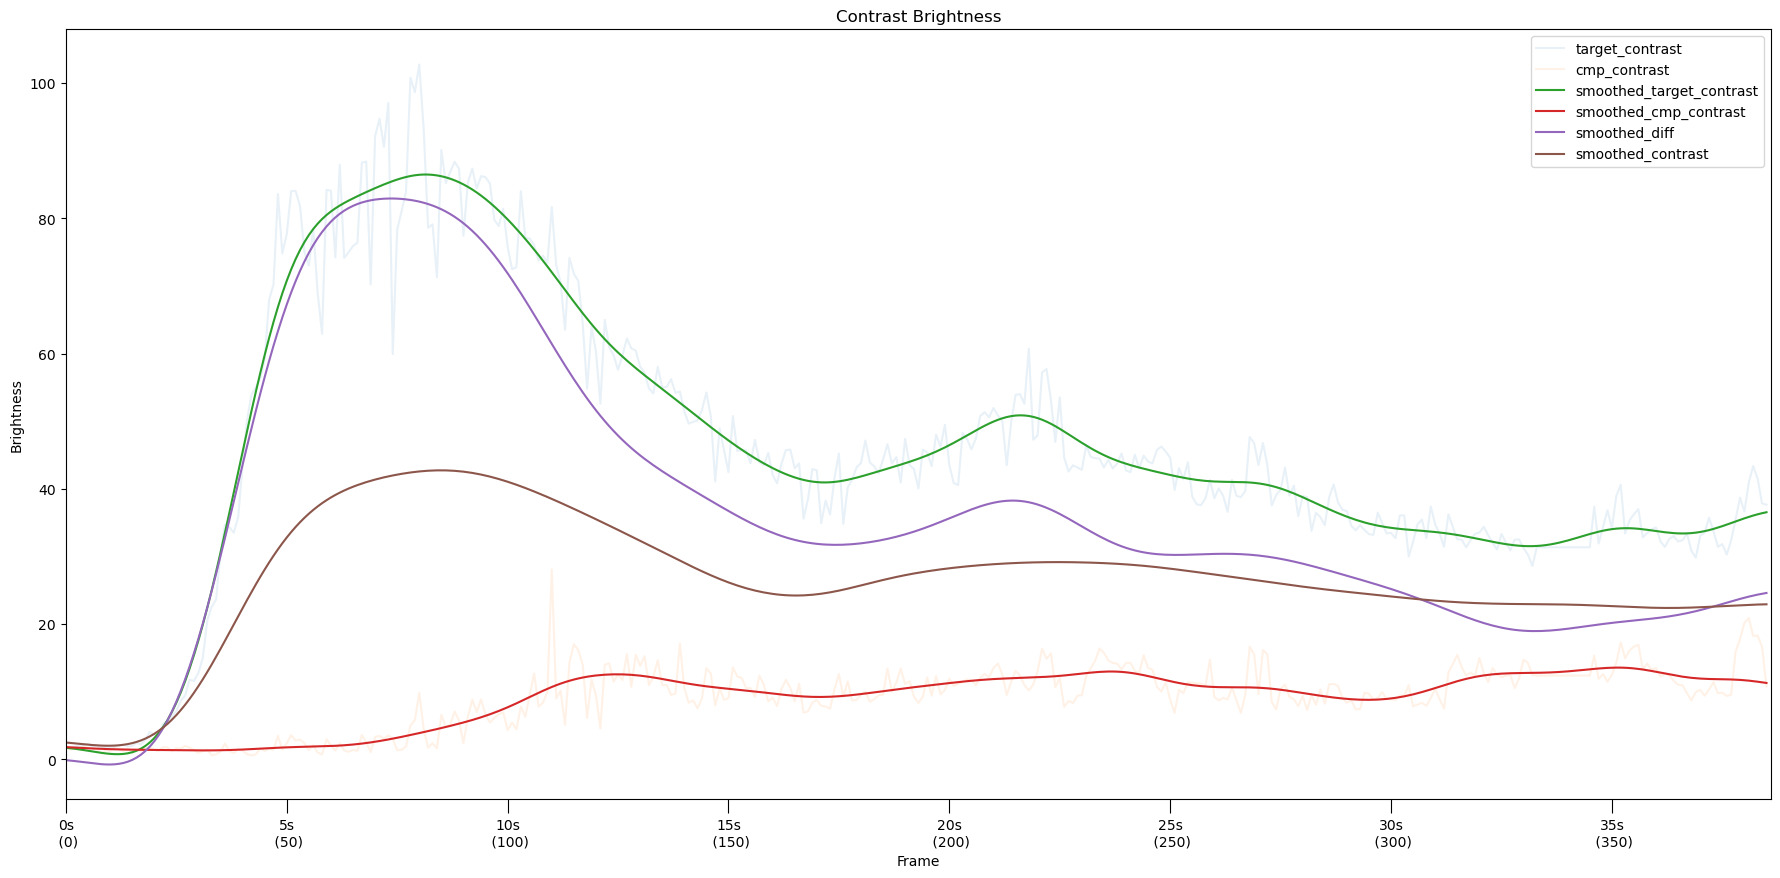

In [73]:
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, butter, lfilter, filtfilt
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.ticker as ticker
ticker.Locator.MAXTICKS = 2500  # 增加 MAXTICKS 限制

target = []
cmp = []
bounding = []

target_contrast = []
cmp_contrast = []
bounding_contrast = []

ultrasound = []
contrast = []

# 设计低通滤波器
def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y


for i in range(1, int(frame_count)+1):
    brightness = history[i]['brightness']

    target.append(brightness[0])
    cmp.append(brightness[1])
    bounding.append(brightness[2])

    target_contrast.append(brightness[3])
    cmp_contrast.append(brightness[4])
    bounding_contrast.append(brightness[5])

    ultrasound.append(brightness[6])
    contrast.append(brightness[7])



fs = int(frame_count)
cutoff = 10
order = 3

smoothed_target = butter_lowpass_filter(target, cutoff, fs, order)
smoothed_cmp = butter_lowpass_filter(cmp, cutoff, fs, order)
smoothed_bounding = butter_lowpass_filter(bounding, cutoff, fs, order)

smoothed_target_contrast = butter_lowpass_filter(target_contrast, cutoff, fs, order)
smoothed_cmp_contrast = butter_lowpass_filter(cmp_contrast, cutoff, fs, order)
smoothed_bounding_contrast = butter_lowpass_filter(bounding_contrast, cutoff, fs, order)

smoothed_ultrasound = butter_lowpass_filter(ultrasound, cutoff, fs, order)
smoothed_contrast = butter_lowpass_filter(contrast, cutoff, fs, order)

diff = butter_lowpass_filter(abs(np.array(target_contrast) - np.array(cmp_contrast)), cutoff, fs, order)
smoothed_diff = butter_lowpass_filter(abs(np.array(smoothed_target_contrast) - np.array(smoothed_cmp_contrast)), cutoff, fs, order)

plt.figure(figsize=(22, 10))
opacity = 0.1

plt.gca().set_xlim(0, int(frame_count))

# 大刻度为秒数，小刻度为帧数
plt.gca().xaxis.set_major_locator(MultipleLocator(fps*5))  # 大刻度间隔为5秒
plt.gca().xaxis.set_minor_locator(MultipleLocator(1))  # 小刻度间隔为1帧

# 设置大刻度标签格式，显示秒数及对应的帧数
def major_formatter(x, pos):
    frames = int(x)
    seconds = int(x / fps)
    return f'{seconds}s\n ({frames})'

plt.gca().xaxis.set_major_formatter(FuncFormatter(major_formatter))

# 关闭小刻度显示
plt.gca().tick_params(which='minor', bottom=False)

# 设置刻度文字的大小和刻度线的长度
plt.tick_params(axis='x', which='major', labelsize=10, length=10)  # 大刻度文字大小和刻度线长度

# plt.figure(figsize=(12, 6))
plt.plot(target_contrast, label='target_contrast', alpha=opacity)
plt.plot(cmp_contrast, label='cmp_contrast', alpha=opacity)
# plt.plot(bounding_contrast, label='bounding_contrast', alpha=opacity)
plt.plot(smoothed_target_contrast, label='smoothed_target_contrast')
plt.plot(smoothed_cmp_contrast, label='smoothed_cmp_contrast')
# plt.plot(smoothed_bounding_contrast, label='smoothed_bounding_contrast')
# plt.plot(diff, label='diff')
plt.plot(smoothed_diff, label='smoothed_diff')

# plt.plot(smoothed_ultrasound, label='smoothed_ultrasound')
plt.plot(smoothed_contrast, label='smoothed_contrast')


plt.legend()
plt.title('Contrast Brightness')
plt.xlabel('Frame')
plt.ylabel('Brightness')

plt.savefig(os.path.join(file_path, 'brightness.png'))

plt.show()


# 查看软件亮度曲线

Frame count: 386/386          Second: 38.60/38.60s
roi1 TTP: 7.16s  roi2 TTP: 6.96s
target TTP: 8.10s
diff TTP: 7.40s
contrast max TTP: 8.5


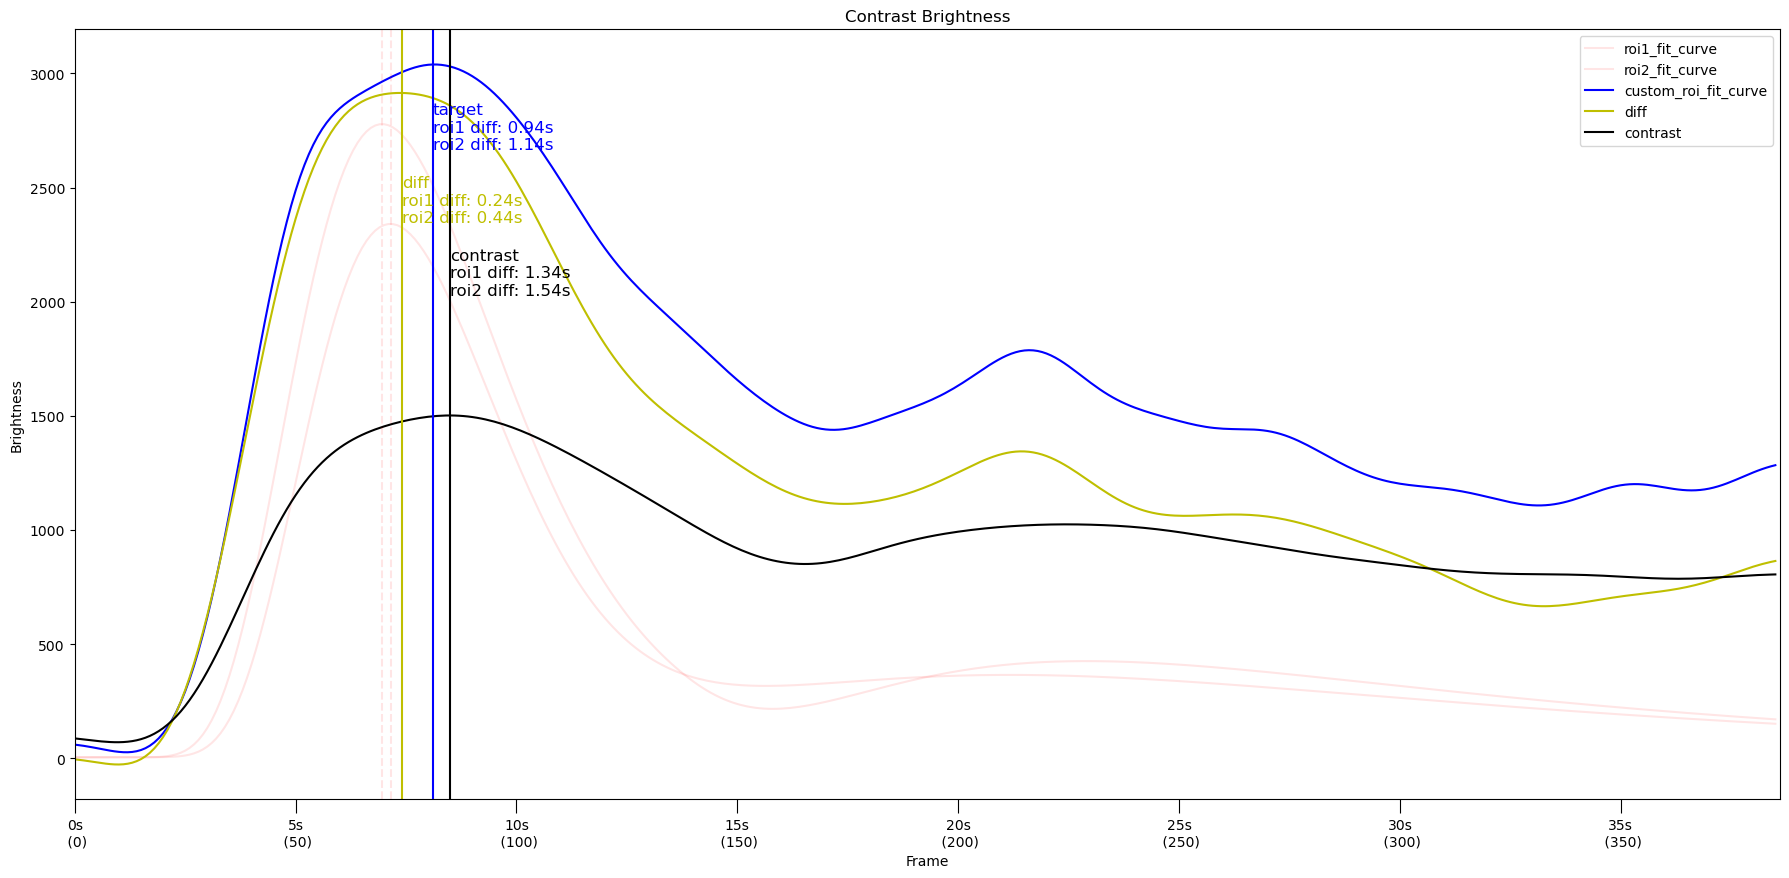

In [74]:
import pandas as pd
import os
import xlrd

l = os.listdir(os.path.join(file_path, "NO NAME"))
excel_file_path = ''
for f in l:
    if f.endswith(".xls"):
        excel_file_path = os.path.join(file_path, "NO NAME", f)
# excel_file_path = os.path.join(file_path, "NO NAME", "NO NAME_Data.xls")

# header=None 其默认第一行当作列名
try:
    df = pd.read_excel(excel_file_path, sheet_name="Sheet1", header=None, engine='xlrd')
except xlrd.XLRDError as e:
    print(f"{e}\nError: Open {excel_file_path} failed!")

roi1_TTP = df.iloc[7, 13]
roi2_TTP = df.iloc[7, 14]

roi1_curve = []
roi2_curve = []
roi1_fit_curve = []
roi2_fit_curve = []
for index, row in df.iterrows():
    if index < 19:
        continue
    roi1_curve.append(row[1])
    roi2_curve.append(row[2])
    roi1_fit_curve.append(row[3])
    roi2_fit_curve.append(row[4])

crop = len(roi1_fit_curve)

custom_roi_curve = np.array(target_contrast)
custom_roi_fit_curve = np.array(smoothed_target_contrast)
brightness_contrast_curve = np.array(smoothed_contrast)

target_TTP = np.argmax(custom_roi_fit_curve[:crop]) / fps
diff_TTP = np.argmax(smoothed_diff[:crop]) / fps
contrast_TTP = np.argmax(brightness_contrast_curve[:crop]) / fps

print(f"Frame count: {crop}/{int(frame_count)}  \
        Second: {crop/fps:.2f}/{frame_count/fps:.2f}s")
print(f"roi1 TTP: {roi1_TTP:.2f}s  roi2 TTP: {roi2_TTP:.2f}s\ntarget TTP: {target_TTP:.2f}s\ndiff TTP: {diff_TTP:.2f}s\ncontrast max TTP: {contrast_TTP}")


opacity = 0.1
plt.figure(figsize=(22, 10))

plt.gca().set_xlim(0, int(frame_count))

plt.gca().xaxis.set_major_locator(MultipleLocator(fps*5))  # 大刻度间隔为5秒
plt.gca().xaxis.set_minor_locator(MultipleLocator(1))  # 小刻度间隔为1帧

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(major_formatter)
)  # 设置大刻度标签格式
plt.gca().tick_params(which="minor", bottom=False)  # 关闭小刻度显示
plt.tick_params(
    axis="x", which="major", labelsize=10, length=10
)  # 大刻度文字大小和刻度线长度

# 绘画软件曲线
# plt.plot(roi1_curve, c='r', label="roi1_curve", alpha=opacity)
# plt.plot(roi2_curve, c='r', label="roi2_curve", alpha=opacity)
plt.plot(roi1_fit_curve, c='r', label="roi1_fit_curve", alpha=opacity)
plt.plot(roi2_fit_curve, c='r', label="roi2_fit_curve", alpha=opacity)

# 绘画自己算出来的曲线
ratio = max(max(roi1_fit_curve), max(roi2_fit_curve)) / max(custom_roi_curve) * 1.3
# plt.plot(custom_roi_curve * ratio, label="custom_roi_curve", alpha=opacity)
plt.plot(custom_roi_fit_curve * ratio, label="custom_roi_fit_curve", color='b')
plt.plot(smoothed_diff * ratio, label='diff', color='y')
plt.plot(smoothed_contrast * ratio, label='contrast', color='black')

# 绘画达峰帧的位置
plt.axvline(x=roi1_TTP * fps, color="r", linestyle="--", alpha=opacity)
plt.axvline(x=roi2_TTP * fps, color="r", linestyle="--", alpha=opacity)

plt.axvline(x=target_TTP * fps, color="b", linestyle="-")
plt.text(
    target_TTP * fps,
    plt.gca().get_ylim()[1]*0.9,
    f"target\nroi1 diff: {abs(roi1_TTP-target_TTP):.2f}s\nroi2 diff: {abs(roi2_TTP-target_TTP):.2f}s",
    fontsize=12,
    color="blue",
    ha="left",
    va="top",
)

plt.axvline(x=diff_TTP * fps, color="y", linestyle="-")
plt.text(
    diff_TTP * fps,
    plt.gca().get_ylim()[1]*0.8,
    f"diff\nroi1 diff: {abs(roi1_TTP-diff_TTP):.2f}s\nroi2 diff: {abs(roi2_TTP-diff_TTP):.2f}s",
    fontsize=12,
    color="y",
    ha="left",
    va="top",
)

plt.axvline(x=contrast_TTP * fps, color="black", linestyle="-")
plt.text(
    contrast_TTP * fps,
    plt.gca().get_ylim()[1]*0.7,
    f"contrast\nroi1 diff: {abs(roi1_TTP-contrast_TTP):.2f}s\nroi2 diff: {abs(roi2_TTP-contrast_TTP):.2f}s",
    fontsize=12,
    color="black",
    ha="left",
    va="top",
)

# 添加标题图标
plt.legend()
plt.title("Contrast Brightness")
plt.xlabel("Frame")
plt.ylabel("Brightness")

# 保存图片
plt.savefig(os.path.join(file_path, "brightness_diff.png"))

plt.show()

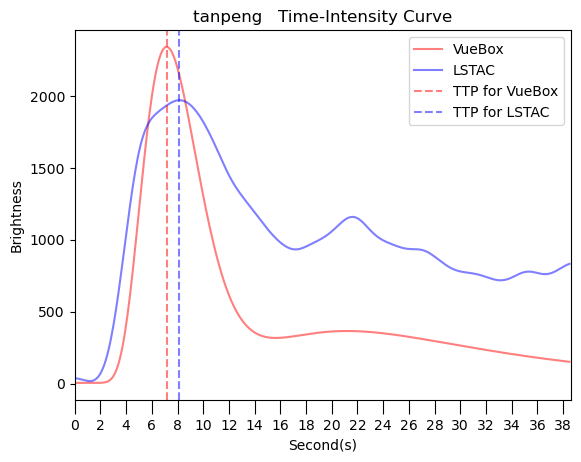

In [75]:
plt.clf()
opacity = 0.5
# plt.figure(figsize=(22, 10))

plt.gca().set_xlim(0, int(frame_count))
interval = 2 if (frame_count / fps) >= 25 else 1
plt.gca().xaxis.set_major_locator(MultipleLocator(fps*interval))  # 大刻度间隔为5秒

def major_formatter(x, pos):
    frames = int(x)
    seconds = int(x / fps)
    return f'{seconds}'
plt.gca().xaxis.set_major_formatter(
    FuncFormatter(major_formatter)
)  # 设置大刻度标签格式
plt.gca().tick_params(which="minor", bottom=False)  # 关闭小刻度显示
plt.tick_params(
    axis="x", which="major", labelsize=10, length=10
)  # 大刻度文字大小和刻度线长度


# 绘画自己算出来的曲线
ratio = max(roi1_fit_curve) / max(custom_roi_curve) * 1
plt.plot(roi1_fit_curve, c='r', label="VueBox", alpha=opacity)
plt.plot(custom_roi_fit_curve * ratio, label="LSTAC", color='b', alpha=opacity)
# plt.plot(smoothed_diff * ratio, label='Strategy 2', color='y')
# plt.plot(smoothed_contrast * ratio, label='Strategy 3', color='black')


# 绘画达峰帧的位置
plt.axvline(x=roi1_TTP * fps, color="r", label='TTP for VueBox', linestyle="--", alpha=opacity)

plt.axvline(x=target_TTP * fps, color="b", label='TTP for LSTAC', linestyle="--", alpha=opacity)
plt.text(
    target_TTP * fps,
    plt.gca().get_ylim()[1]*0.9,
    f" ",
    fontsize=12,
    color="blue",
    ha="left",
    va="top",
)

# 添加标题图标
plt.legend()
plt.title(f"{name.replace('_origin.mp4', '')}   Time-Intensity Curve")
plt.xlabel("Second(s)")
plt.ylabel("Brightness")

# 保存图片
plt.savefig(os.path.join(file_path, "brightness_diff_simple.png"))

plt.show()

with open(os.path.join(file_path, "ttp_curve.txt"), "w", encoding="utf-8") as file:
    file.write(f'First line is VueBox, second line is LSTAC\n')
    file.write(' '.join([str(i) for i in roi1_fit_curve]) + "\n")
    file.write(' '.join([str(i) for i in custom_roi_fit_curve]))

# 查看标签中心点分布情况

Find center points: 100%|██████████| 386/386.0 [00:00<00:00, 218813.53it/s]


Outliers from history: []
Outliers from process: []


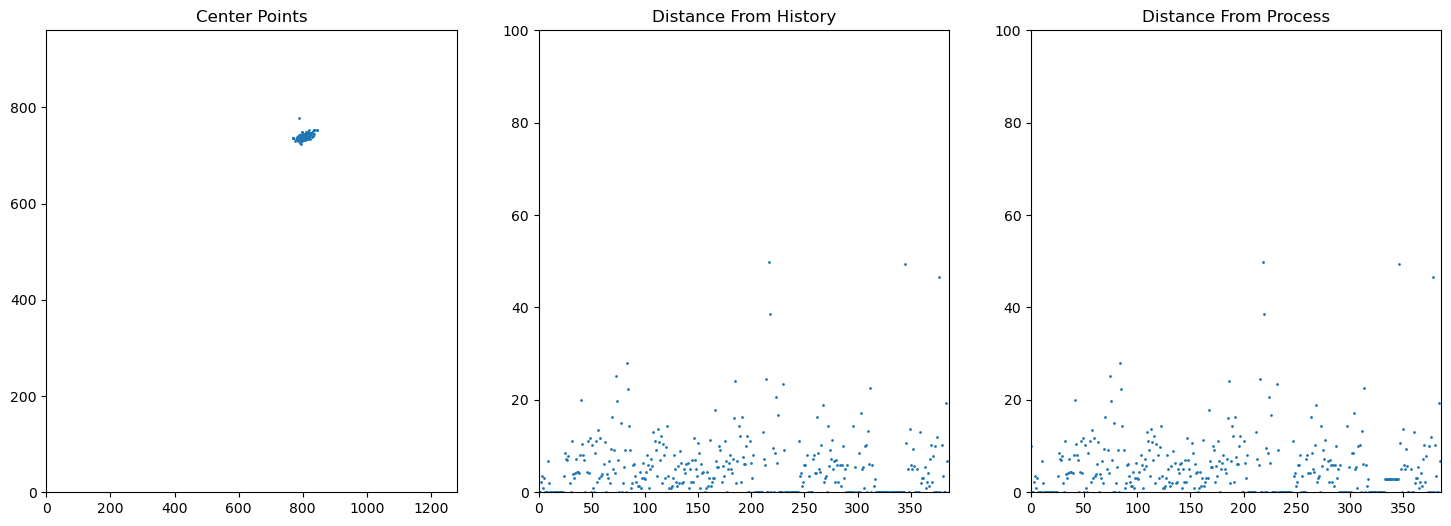

In [76]:
import sys
import os
from contextlib import contextmanager
from matplotlib import pyplot as plt
import math


# 对每一帧计算第一个中心点坐标
center_points = []
dis = []
pbar = tqdm(total=frame_count, desc="Find center points")
for i in range(int(frame_count)):
    pbar.update(1)
    center_points.append(get_center(history[i+1]['rect'][0]))
    dis.append(history[i+1]['distance'])
pbar.close()

distance = []
for index in range(1, len(center_points)):
    distance.append(get_distance(center_points[index-1], center_points[index]))

fig, ax = plt.subplots(ncols=3, nrows=1, figsize=(18, 6))
ax[0].scatter([point[0] for point in center_points], [point[1] for point in center_points], s=1)
ax[0].set_xlim(0, width)
ax[0].set_ylim(0, height)
ax[0].set_title('Center Points')
 
ax[1].scatter([i for i in range(len(distance))], distance, s=1)
ax[1].set_xlim(0, frame_count)
ax[1].set_ylim(0, 100)
ax[1].set_title('Distance From History')

ax[2].scatter([i for i in range(len(dis))], dis, s=1)
ax[2].set_xlim(0, frame_count)
ax[2].set_ylim(0, 100)
ax[2].set_title('Distance From Process')


print('Outliers from history:', [index+1 for index, value in enumerate(distance) if value > distance_threshold])
print('Outliers from process:', [index+1 for index, value in enumerate(dis) if value > distance_threshold])

plt.savefig(os.path.join(file_path, 'Center points distribution.png'))

# 保存一些指标

In [77]:
import os

label_file_list = os.listdir(labels_path)
label_file_list.insert(0, "label_file_list")

lost_frame_count = len(lost_frame)
confidence_list = []


start = label_file_list[1].rfind("_") + 1
prefix = label_file_list[1][:start]

# 找到所有标框的置信度
for i in range(1, int(frame_count)):
    if i in lost_frame:
        continue
    label_file = os.path.join(labels_path, prefix + f"{i}.txt")
    if os.path.exists(label_file):
        # print(label_file)
        _, _, _, conf_list = get_label_info(label_file)
        confidence_list.extend([float(c) for c in conf_list[0]])

confidence_list.sort()

medium_confidence = confidence_list[int(len(confidence_list) / 2)]
average_confidence = sum(confidence_list) / len(confidence_list)
lost_frame_ratio = lost_frame_count / frame_count
lost_frame_second = lost_frame_count / fps

with open(os.path.join(file_path, "metrics.txt"), "w", encoding="utf-8") as file:
    file.write(
        f"\
fps {fps}\n\
frame_count {frame_count}\n\
resolution {width} {height}\n\
duration {frame_count/fps}\n\
medium_confidence {medium_confidence}\n\
average_confidence {average_confidence}\n\
lost_frame_ratio {lost_frame_ratio}\n\
lost_frame_second {lost_frame_second}\n\
roi1_TTP {roi1_TTP}\n\
roi2_TTP {roi2_TTP}\n\
target_TTP {target_TTP}\n\
diff_TTP {diff_TTP}\n\
contrast_TTP {contrast_TTP}\n\
"
    )


if math.isnan(roi1_TTP):
    print("roi1_TTP is nan")
    roi1_TTP = roi2_TTP
if math.isnan(roi2_TTP):
    print("roi2_TTP is nan")
    roi2_TTP = roi1_TTP

print(f"roi1_TTP: {roi1_TTP:.2f}  roi2_TTP: {roi2_TTP: .2f} target_TTP: {target_TTP: .2f}  diff_TTP: {diff_TTP: .2f}  contrast_TTP: {contrast_TTP: .2f}")
 
ttp_path = os.path.join(file_path, "TTP")
os.makedirs(ttp_path, exist_ok=True)
cv2.imwrite(os.path.join(ttp_path, 'roi1_TTP.jpg'), frame_pure_noModified_list[int(roi1_TTP*fps)])
cv2.imwrite(os.path.join(ttp_path, 'roi2_TTP.jpg'), frame_pure_noModified_list[int(roi2_TTP*fps)])
cv2.imwrite(os.path.join(ttp_path, 'target_TTP.jpg'), frame_pure_noModified_list[int(target_TTP*fps)])
cv2.imwrite(os.path.join(ttp_path, 'diff_TTP.jpg'), frame_pure_noModified_list[int(diff_TTP*fps)])
cv2.imwrite(os.path.join(ttp_path, 'contrast_TTP.jpg'), frame_pure_noModified_list[int(contrast_TTP*fps)])
print('Save TTP images successfully!')

roi1_TTP: 7.16  roi2_TTP:  6.96 target_TTP:  8.10  diff_TTP:  7.40  contrast_TTP:  8.50
Save TTP images successfully!


# LOF处理离群值

Outlier Indices: [219, 227, 228, 229, 230, 231, 272, 273, 347, 348, 349, 350, 379, 380, 381, 382, 383, 384]


(0.0, 960.0)

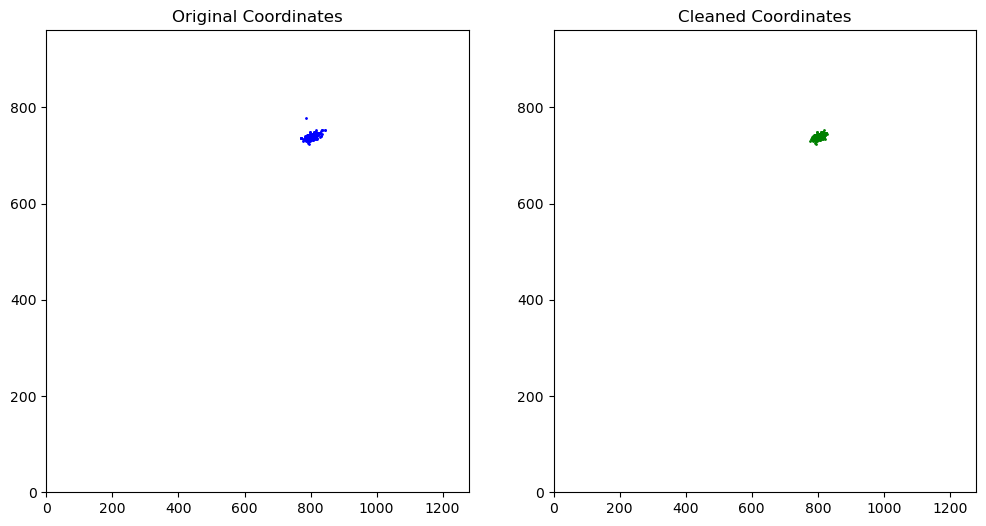

In [78]:
from matplotlib import pyplot as plt
from sklearn.neighbors import LocalOutlierFactor
import numpy as np
from scipy.spatial import distance

def detect_and_replace_outliers_lof(coordinates, n_neighbors=20, contamination='auto'):
    """ 使用 LOF 检测并替换二维坐标序列中的离群值 """
    cleaned_coordinates = coordinates.copy()

    # 使用 LOF 检测离群值
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    lof_labels = lof.fit_predict(coordinates)
    
    outlier_indices = [index+1 for index, label in enumerate(lof_labels) if label == -1]
    
    # 遍历每个点，将离群值替换为之前最近的一个非离群值
    for index, label in enumerate(lof_labels):
        if label == -1:  # -1 表示离群值
            i = index
            while i >= 0 and label == -1:
                i -= 1
            cleaned_coordinates[index] = coordinates[i]
                
    return cleaned_coordinates, outlier_indices

# 示例数据
coordinates = np.array([point for point in center_points])

# 处理离群值
cleaned_coordinates, outlier_indices = detect_and_replace_outliers_lof(coordinates, n_neighbors=280)
# print("Original Coordinates:\n", coordinates)
# print("Cleaned Coordinates:\n", cleaned_coordinates)
print("Outlier Indices:", outlier_indices)


fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].scatter(coordinates[:, 0], coordinates[:, 1], color='blue', s=1)
axs[0].set_title('Original Coordinates')
axs[1].scatter(cleaned_coordinates[:, 0], cleaned_coordinates[:, 1], color='green', s=1)
axs[1].set_title('Cleaned Coordinates')

axs[0].set_xlim(0, width)
axs[0].set_ylim(0, height)
axs[1].set_xlim(0, width)
axs[1].set_ylim(0, height)

# 查看帧处理效果

In [79]:
from ipywidgets import interact, widgets

def cv2mat(frame):
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

# frame_index从1开始
@interact(frame_index=widgets.IntSlider(min=1, max=frame_count, step=1, value=1))
def show(frame_index):
    frame_index = frame_index - 1
    
    # frame = process_frame(frame_origin_list[frame_index], frame_index+1)
    frame = frame_origin_list[frame_index]
    
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 5), dpi=300)  
    
    axs[0].imshow(cv2mat(frame_list[frame_index]))
    axs[0].set_title('yolo')
    
    axs[1].imshow(cv2mat(frame))
    axs[1].set_title('origin')
    
    print(f'分辨率：{int(width)}*{int(height)}  ', f'帧率：{fps}  ' ,'时长:', '%.2f'%(frame_index/fps), '/', '%.2f'%(frame_count/fps), sep='')
    

interactive(children=(IntSlider(value=1, description='frame_index', max=386, min=1), Output()), _dom_classes=(…